In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from swmm_api import read_out_file
import os

E:\Anaconda\envs\drainage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib import rcParams

config = {
            "font.family": 'serif',
            "font.size": 22,
            "mathtext.fontset": 'stix',
            "font.serif": ['Times New Roman'],
            'axes.unicode_minus': False 
         }
rcParams.update(config)

In [3]:
train_rewards = {}
train_rewards['DRL-Original']=np.load('./Results_DQN_reward3/Results/Train.npy',allow_pickle=True).tolist()['Episode_reward'][:500]
train_rewards['DRL-GLI']=np.load('./Results_DQN_reward5/Results/Train_GI.npy',allow_pickle=True).tolist()['Episode_reward']

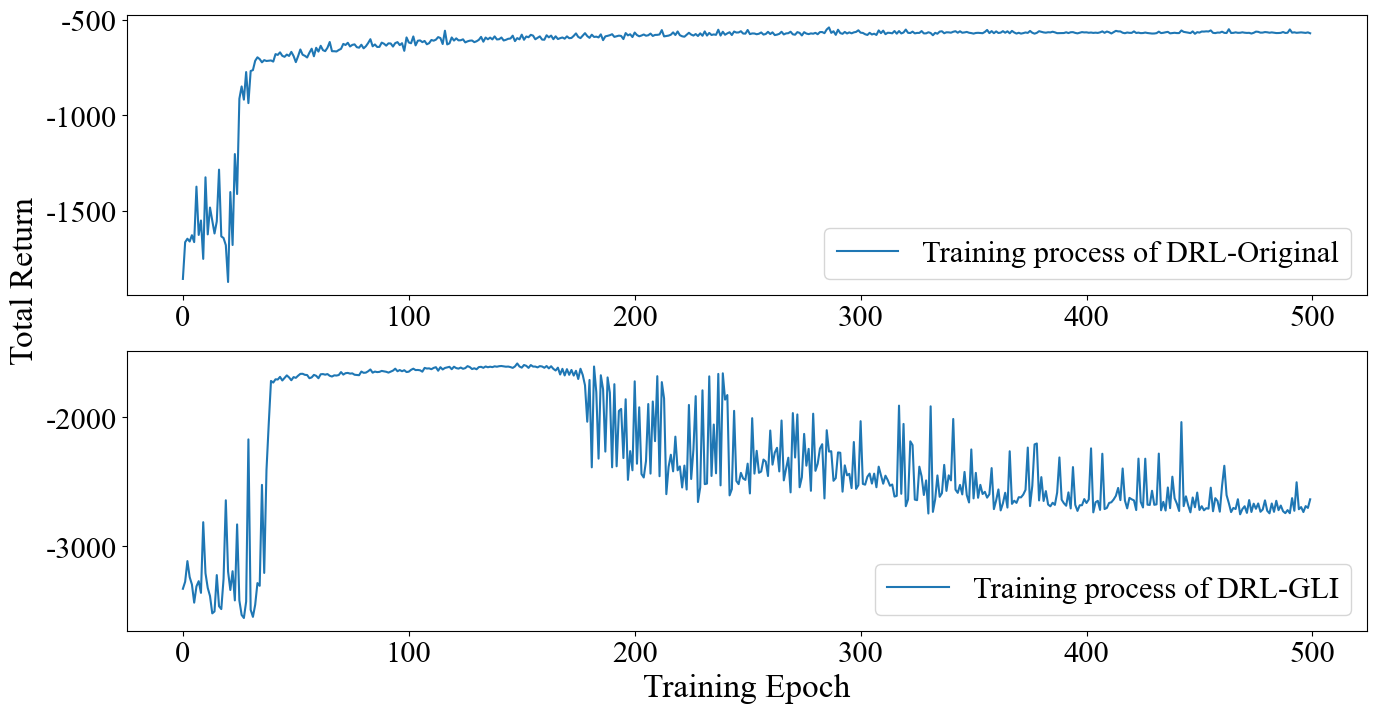

In [4]:
fig,ax = plt.subplots(2,1,figsize=(16,8))
ax[0].plot(train_rewards['DRL-Original'],label='Training process of DRL-Original')
ax[1].plot(train_rewards['DRL-GLI'],label='Training process of DRL-GLI')

for i in range(2):
    ax[i].legend()

#for i in range(5):
#    ax[i].set_xticks([],[])

ax[0].set_ylabel('Total Return'+30*' ',fontsize=24)
ax[1].set_xlabel('Training Epoch',fontsize=24)

plt.savefig('./DRL_train.png',dpi=200,bbox_inches='tight')